<a href="https://colab.research.google.com/github/IanPerigoUERN/NexVisual/blob/main/NexVisual_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projetos reais de visão computacional**

In [1]:
!pip install torch torchvision huggingface_hub ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.0 MB/s eta 0:00:00


In [2]:
import yaml
import os

from ultralytics import YOLO
from huggingface_hub import snapshot_download
from pathlib import Path
import shutil
from IPython.display import Video
from datasets import load_dataset

import matplotlib.pyplot as plt
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
dataset = load_dataset("abhilash88/fer2013-enhanced")

# Access splits
train_data = dataset["train"]
validation_data = dataset["validation"]
test_data = dataset["test"]

print(f"Training samples: {len(train_data):,}")
print(f"Features: {train_data.features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.8k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/171M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/36.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25117 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5380 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5390 [00:00<?, ? examples/s]

Training samples: 25,117
Features: {'sample_id': Value('string'), 'image': Array2D(shape=(48, 48), dtype='uint8'), 'emotion': ClassLabel(names=['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']), 'emotion_name': Value('string'), 'pixels': Value('string'), 'usage': Value('string'), 'quality_score': Value('float32'), 'brightness': Value('float32'), 'contrast': Value('float32'), 'sample_weight': Value('float32'), 'pixel_mean': Value('float32'), 'pixel_std': Value('float32'), 'pixel_min': Value('uint8'), 'pixel_max': Value('uint8'), 'edge_score': Value('float32'), 'focus_score': Value('float32'), 'brightness_score': Value('float32')}


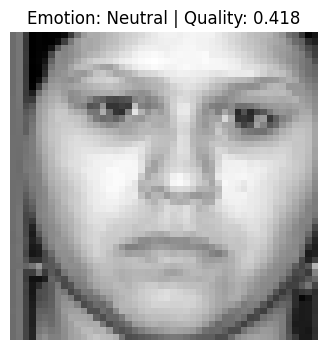

Sample ID: fer2013_006289
Emotion: neutral (class 6)
Quality Score: 0.418
Brightness: 138.1
Contrast: 45.6


In [4]:



# Get a sample
sample = train_data[0]

# Display image and info
image = sample["image"]
emotion = sample["emotion_name"]
quality = sample["quality_score"]

plt.figure(figsize=(6, 4))
plt.imshow(image, cmap='gray')
plt.title(f'Emotion: {emotion.capitalize()} | Quality: {quality:.3f}')
plt.axis('off')
plt.show()

print(f"Sample ID: {sample['sample_id']}")
print(f"Emotion: {emotion} (class {sample['emotion']})")
print(f"Quality Score: {quality:.3f}")
print(f"Brightness: {sample['brightness']:.1f}")
print(f"Contrast: {sample['contrast']:.1f}")


In [5]:
sample = train_data[0]

print(type(sample["image"]))
print(len(sample["image"]))
print(len(sample["image"][0]))

<class 'list'>
48
48


In [6]:
import torch
import torchvision.models as models

model = models.resnet18(weights="DEFAULT")

num_features = model.fc.in_features

model.fc = torch.nn.Linear(
    num_features,
    7
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


In [7]:
from PIL import Image
import numpy as np
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
def transform_batch(batch):

    images = []

    for img in batch["image"]:

        img = np.array(img, dtype=np.uint8)

        img = Image.fromarray(img)

        img = transform(img)

        images.append(img)

    batch["pixel_values"] = images

    return batch

In [9]:
train_data.set_transform(transform_batch)

validation_data.set_transform(transform_batch)

test_data.set_transform(transform_batch)

In [10]:
sample = train_data[0]

print(sample["pixel_values"].shape)

torch.Size([3, 224, 224])


In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    validation_data,
    batch_size=64
)

test_loader = DataLoader(
    test_data,
    batch_size=64
)

In [12]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

for batch in train_loader:

    images = batch["pixel_values"].to(device)

    labels = batch["emotion"].to(device)

    outputs = model(images)

    loss = criterion(
        outputs,
        labels
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

In [14]:
torch.save(
    model.state_dict(),
    "fer_resnet18.pth"
)

In [15]:
import cv2

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

In [16]:
model = models.resnet18(weights=None)

model.fc = torch.nn.Linear(
    model.fc.in_features,
    7
)

model.load_state_dict(
    torch.load(
        "fer_resnet18.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
from IPython.display import Javascript
from google.colab.output import eval_js
from base64 import b64decode

In [52]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capturar';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';

          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;

          await video.play();

          google.colab.output.setIframeHeight(document.body.scrollHeight, true);

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');

          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;

          canvas.getContext('2d')
                .drawImage(video, 0, 0);

          stream.getTracks()[0].stop();
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    # Esta parte deve ficar DENTRO da função!
    display(js)
    data = eval_js(f'takePhoto({quality})')
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

<IPython.core.display.Javascript object>

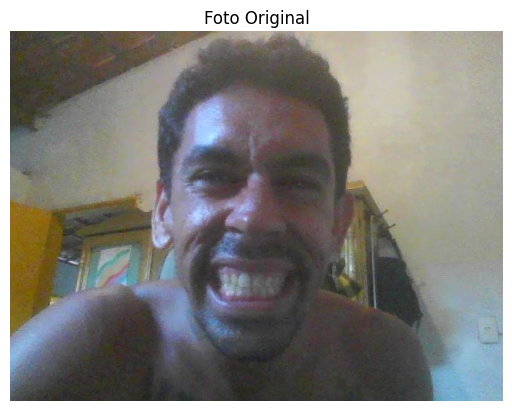

Rostos encontrados: 1


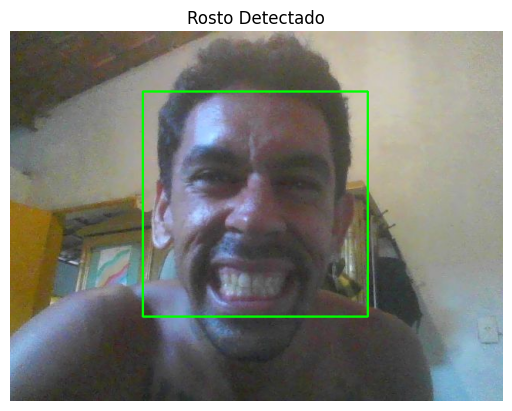

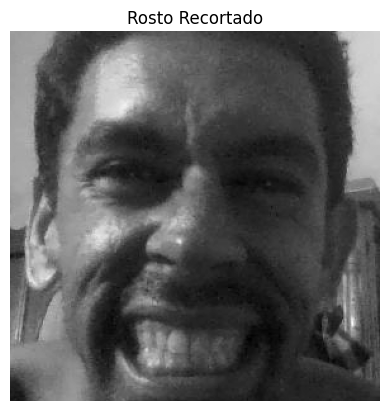

Emoção Detectada: happy


In [96]:
# 1. Tira a foto
try:
    photo = take_photo()
except Exception as err:
    print(f"Erro ao ligar a webcam: {err}")

# 2. Lê a imagem original salva
image = cv2.imread("photo.jpg")

# Mostra a imagem original
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Foto Original")
plt.axis("off")
plt.show()

# 3. Prepara o detector de rostos
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.07, # se não achar o rosto, baixar para 1.05
    minNeighbors=4,  # se não achar o rosto, baixar para 3 ou 4
    minSize=(30, 30)
)

print(f"Rostos encontrados: {len(faces)}")

# 4. Processa apenas se encontrou algum rosto
if len(faces) > 0:
    # Desenha o retângulo em todos os rostos
    for (x,y,w,h) in faces:
        cv2.rectangle(image, (x,y), (x+w,y+h), (0,255,0), 2)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Rosto Detectado")
    plt.axis("off")
    plt.show()

    # Pega apenas o primeiro rosto para a predição da emoção
    x, y, w, h = faces[0]
    face = gray[y:y+h, x:x+w]

    plt.imshow(face, cmap="gray")
    plt.title("Rosto Recortado")
    plt.axis("off")
    plt.show()

    # ==========================================
    # PREDIÇÃO (Requer PyTorch configurado)
    # ==========================================
    face_pil = Image.fromarray(face)
    input_tensor = transform(face_pil)
    input_tensor = input_tensor.unsqueeze(0)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(1)

    emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
    print(f"Emoção Detectada: {emotion_labels[pred.item()]}")

else:
    print("O detector não conseguiu achar um rosto. Certifique-se de que o ambiente está bem iluminado e você está olhando para a câmera.")

# **Reconhecimento de texto com OCR**

In [97]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 33.6 MB/s eta 0:00:00


In [98]:
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

In [99]:
#### carregar imagens do drive

nex_text =''

num_text = ''

In [100]:
reader = easyocr.Reader(["en"]) # Carrega o modelo de inglês para a memória.

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [ ]:
plt.imshow(nex_text)
result = reader.readtext('text', detail=0)
print(result)

In [ ]:
plt.imshow(num_text)
result = reader.readtext("num", detail=0)
print(result)

- [ ] Altere o parâmetro `detail` para `1` e tente desenhar as informações de bounding box na imagem.